In [1]:
from rdkit.Chem import DataStructs
from rdkit.DataStructs.cDataStructs import ExplicitBitVect
import pandas as pd
import numpy as np

In [2]:
emb_morgan_df = pd.read_csv('emb_morgan_df.csv')
emb_morgan_df

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,MP
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,355.15
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,373.65
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,373.75
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,373.70
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,374.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117747,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,395.65
117748,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,396.15
117749,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,327.65
117750,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,488.15


In [3]:
fp1 = emb_morgan_df.iloc[13][:-1]
fp1.min()

0.0

**calculate Tanimoto analysis on over 100,000 is very compute-expensive**

In [3]:
def sample_dataset(df, n_samples=10000, random_state=42):
    """Randomly sample n molecules from dataset"""
    if len(df) > n_samples:
        df_sampled = df.sample(n=n_samples, random_state=random_state).reset_index(drop=True)
        print(f"Sampled {n_samples} molecules from {len(df)} total")
    else:
        df_sampled = df.copy()
        print(f"Using all {len(df)} molecules")
    return df_sampled

emb_morgan_df_sampled = sample_dataset(emb_morgan_df, n_samples=1000)
emb_morgan_df_sampled

Sampled 1000 molecules from 117752 total


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,MP
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,506.65
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,456.00
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,197.55
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,409.15
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,346.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,352.15
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,427.65
997,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,402.15
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,444.15


In [4]:
def tanimoto_similarity_vectorized(fp_array):
    """
    Vectorized Tanimoto similarity calculation
    fp_array: numpy array of shape (n_molecules, n_features)
    Returns: similarity matrix of shape (n_molecules, n_molecules)
    """
    # Convert to binary (in case there are any non-binary values)
    fp_binary = (fp_array > 0).astype(np.int8)
    
    # Calculate intersection using matrix multiplication
    # This gives us the dot product = number of common 1s
    intersection = np.dot(fp_binary, fp_binary.T)
    
    # Calculate number of 1s in each fingerprint
    sum_vec = np.sum(fp_binary, axis=1)
    
    # Calculate union using broadcasting
    # Union[i,j] = sum_vec[i] + sum_vec[j] - intersection[i,j]
    sum_matrix = sum_vec[:, np.newaxis] + sum_vec[np.newaxis, :]
    union = sum_matrix - intersection
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        similarity = np.divide(intersection, union, where=union != 0)
        similarity[union == 0] = 0
    
    return similarity

fp_array = emb_morgan_df_sampled.drop(columns=['MP']).values.astype(np.int8)
assert fp_array.shape[-1] == 2 * 2048, fp_array.shape

print("Calculating vectorized Tanimoto similarity...")
similarity_matrix = tanimoto_similarity_vectorized(fp_array)
 
# Create DataFrame with indices
similarity_df = pd.DataFrame(similarity_matrix, index=emb_morgan_df_sampled.index, columns=emb_morgan_df_sampled.index)

Calculating vectorized Tanimoto similarity...


In [5]:
similarity_df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,1.000000,0.151724,0.028037,0.244604,0.132353,0.124224,0.124138,0.000000,0.093023,0.147651,...,0.121951,0.156463,0.114865,0.138554,0.131868,0.119205,0.205479,0.033898,0.124224,0.067416
1,0.151724,1.000000,0.020619,0.255814,0.201681,0.164384,0.235772,0.017857,0.092593,0.221374,...,0.161074,0.195489,0.076923,0.178808,0.196319,0.179104,0.137931,0.018349,0.205674,0.059172
2,0.028037,0.020619,1.000000,0.019417,0.048780,0.018018,0.043956,0.036364,0.016949,0.040404,...,0.000000,0.020000,0.065934,0.034188,0.000000,0.000000,0.000000,0.080000,0.036697,0.051724
3,0.244604,0.255814,0.019417,1.000000,0.211382,0.173333,0.206107,0.000000,0.143750,0.248120,...,0.147436,0.204380,0.081081,0.194805,0.175439,0.197080,0.147651,0.044643,0.189189,0.101190
4,0.132353,0.201681,0.048780,0.211382,1.000000,0.207692,0.275229,0.020202,0.064935,0.256410,...,0.159420,0.269565,0.110236,0.222222,0.221477,0.294643,0.151515,0.166667,0.180451,0.092105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.119205,0.179104,0.000000,0.197080,0.294643,0.283582,0.166667,0.074074,0.059172,0.208955,...,0.143791,0.248062,0.068493,0.184211,0.262821,1.000000,0.136054,0.018018,0.146667,0.058480
996,0.205479,0.137931,0.000000,0.147651,0.151515,0.125786,0.110345,0.016529,0.081395,0.119205,...,0.137500,0.135135,0.051613,0.119760,0.139665,0.136054,1.000000,0.052632,0.125786,0.068182
997,0.033898,0.018349,0.080000,0.044643,0.166667,0.024590,0.103093,0.029851,0.031250,0.036036,...,0.049180,0.017857,0.079208,0.031008,0.013514,0.018018,0.052632,1.000000,0.033058,0.046875
998,0.124224,0.205674,0.036697,0.189189,0.180451,0.135802,0.169014,0.032258,0.085227,0.191781,...,0.183544,0.176871,0.135135,0.230769,0.135870,0.146667,0.125786,0.033058,1.000000,0.128655


Total pairwise comparisons: 499,500


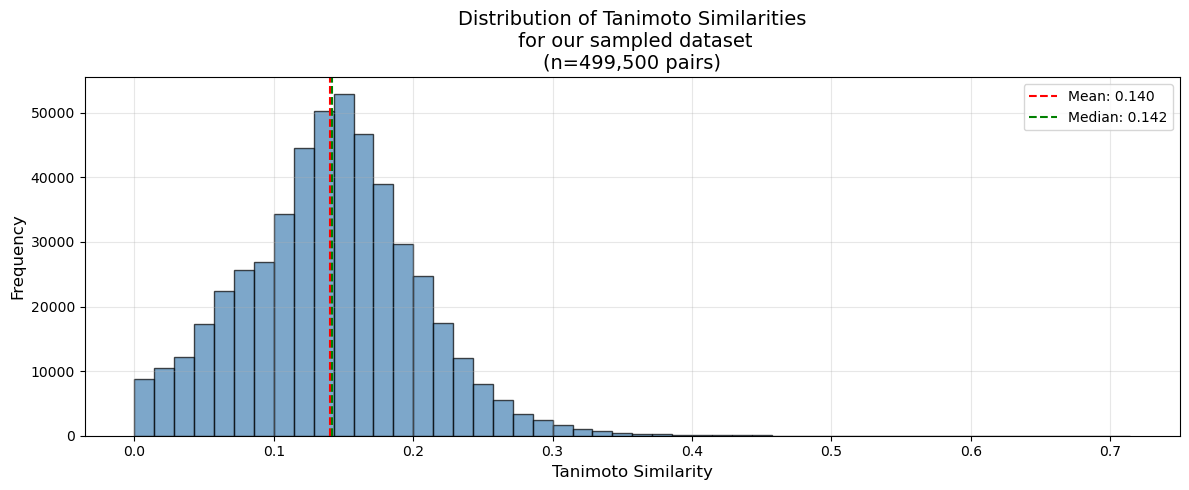


📊 Similarity Statistics:
Number of pairs: 499,500
Mean: 0.1404
Median: 0.1417
Std: 0.0624
Min: 0.0000
Max: 0.7143

📈 Percentiles:
1th: 0.0000
5th: 0.0354
10th: 0.0577
25th: 0.1000
50th: 0.1417
75th: 0.1791
90th: 0.2167
95th: 0.2416
99th: 0.2992


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get all unique pairwise similarities (excluding diagonal and duplicates)
# Upper triangle indices (k=1 excludes diagonal)
upper_tri_indices = np.triu_indices_from(similarity_matrix, k=1)
similarities = similarity_matrix[upper_tri_indices]

print(f"Total pairwise comparisons: {len(similarities):,}")

# ============================================
# 1. BASIC HISTOGRAM
# ============================================
plt.figure(figsize=(12, 5))

plt.hist(similarities, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Tanimoto Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Tanimoto Similarities\n for our sampled dataset\n(n={len(similarities):,} pairs)', fontsize=14)
plt.grid(True, alpha=0.3)

# Add statistics
plt.axvline(np.mean(similarities), color='red', linestyle='--', 
            label=f'Mean: {np.mean(similarities):.3f}')
plt.axvline(np.median(similarities), color='green', linestyle='--', 
            label=f'Median: {np.median(similarities):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 3. PRINT STATISTICS
# ============================================
print("\nSimilarity Statistics:")
print(f"Number of pairs: {len(similarities):,}")
print(f"Mean: {np.mean(similarities):.4f}")
print(f"Median: {np.median(similarities):.4f}")
print(f"Std: {np.std(similarities):.4f}")
print(f"Min: {np.min(similarities):.4f}")
print(f"Max: {np.max(similarities):.4f}")

# Percentiles
print("\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}th: {np.percentile(similarities, p):.4f}")


In [7]:
chembl_df = pd.read_csv("/home/dubonos/MELTING-POINT-1/chembl_cleaned.csv")
chembl_df

,smiles
0,Cc1cc(-c2csc(N=C(N)N)n2)cn1C
1,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1
2,COc1c(O)cc(O)c(C(=N)Cc2ccc(O)cc2)c1O
3,CCOC(=O)c1cc2cc(C(=O)O)ccc2[nH]1
4,CC(=O)O[C@H]1/C(C)=C\[C@@H]2OC(=O)[C@]3(C)O[C@...
...,...
1789378,CCOC(C)(C)[C@H](F)CNC(=O)c1cnc(-n2ccc3cc(C#N)c...
1789379,C[C@@H]1CCC[C@H](N2CCC(c3c(F)ccc(Cl)c3F)=CC2=O...
1789380,Cc1cc(-c2noc(C(C)Nc3nccc(N4C(=O)OCC4[C@@H](C)O...
1789381,CC[C@@H](NC(=O)c1cc(C(=O)N[C@H](C)c2ccc(F)cc2)...


In [8]:
chembl_df_sampled = sample_dataset(chembl_df, n_samples=1000)
chembl_df_sampled

Sampled 1000 molecules from 1789383 total


,smiles
0,COc1ccc(CNC(=O)CN(CCC(C)C)S(=O)(=O)c2ccc3c(c2)...
1,Cc1cccc(-c2ccc3c(c2)C2CC3CCN2C)c1
2,COc1ccccc1NC(=O)c1ccc2nc(-c3ccccc3)c(-c3ccccc3...
3,COc1cc2ncnc(N(C)c3cccc(NC(=O)Nc4ccccc4)c3)c2cc1OC
4,CCN(C)C(=O)CNC(=O)CNC(=O)[C@H](C)NC(=O)[C@H](C...
...,...
995,O=C(NCC1CSC1)c1ccc2cc(Oc3ccc(C(F)(F)F)cn3)ccc2n1
996,C#Cc1ccc(NC(=O)C2(C)CCN2C(=O)Cc2ccc(C(C)C)cc2)cc1
997,CC(C)=CCc1cc(C(=O)Nc2cc3ccc(O[C@H]4C[C@H](O)CO...
998,COCC(=O)Nc1nc(C)c(C(=O)N[C@@H](C)c2ccc(OC3CCN(...


In [10]:
import time
t0start = time.time() 

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [11]:
%%time
fingerprints = []
    
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# Create a Morgan fingerprint generator
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
for smi in chembl_df_sampled["smiles"]:
    mol = Chem.MolFromSmiles(smi)
    fp = morgan_generator.GetFingerprint(mol) 
    arr = np.array(fp)
    fingerprints.append(arr)


CPU times: user 1.62 s, sys: 162 µs, total: 1.62 s
Wall time: 1.62 s


In [12]:
X_morgan = pd.DataFrame(np.array(fingerprints))
X_morgan

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
%%time
fingerprints3 = []

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048)
for smi in chembl_df_sampled["smiles"]:
    mol = Chem.MolFromSmiles(smi)
    fp = morgan_generator.GetFingerprint(mol) 
    arr = np.array(fp)
    fingerprints3.append(arr)

CPU times: user 1.67 s, sys: 4.02 ms, total: 1.68 s
Wall time: 1.68 s


In [14]:
X_morgan3 = pd.DataFrame(np.array(fingerprints3))
X_morgan3

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
996,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
emb_morgan_chembl = pd.concat([X_morgan, X_morgan3], ignore_index=True, axis=1)
emb_morgan_chembl

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
996,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
emb_morgan_chembl

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
996,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
fp_array = emb_morgan_chembl.values.astype(np.int8)
assert fp_array.shape[-1] == 2 * 2048, fp_array.shape

print("Calculating vectorized Tanimoto similarity...")
similarity_matrix_chembl = tanimoto_similarity_vectorized(fp_array)
 
# Create DataFrame with indices
similarity_df_chembl = pd.DataFrame(similarity_matrix_chembl, index=emb_morgan_chembl.index, columns=emb_morgan_chembl.index)

similarity_df_chembl

Calculating vectorized Tanimoto similarity...


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,-0.316195,0.072464,0.117371,0.113537,0.147826,0.126829,0.152174,0.195000,0.096774,0.123810,...,0.077586,0.120301,0.070866,0.147727,0.142202,0.141631,0.140187,0.116732,0.143396,0.128319
1,0.072464,1.000000,0.102273,0.082051,0.067961,0.068571,0.070064,0.140351,0.121387,0.097143,...,0.119565,0.104348,0.096154,0.082192,0.102151,0.088235,0.081081,0.099548,0.111588,0.098958
2,0.117371,0.102273,1.000000,0.220430,0.134615,0.097297,0.108434,0.185393,0.153846,0.216374,...,0.099010,0.129707,0.119266,0.129870,0.169312,0.138756,0.096447,0.188073,0.117886,0.123762
3,0.113537,0.082051,0.220430,1.000000,0.129464,0.083744,0.110497,0.206349,0.112745,0.165803,...,0.086364,0.148000,0.139738,0.136905,0.133333,0.118421,0.114833,0.104000,0.114504,0.119266
4,0.147826,0.067961,0.134615,0.129464,-0.322997,0.117073,0.082474,0.161765,0.123810,0.083333,...,0.112108,0.096296,0.115702,0.086957,0.176190,0.090909,0.115207,0.075472,0.114815,0.124444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.141631,0.088235,0.138756,0.118421,0.090909,0.105263,0.109948,0.165854,0.091743,0.140097,...,0.106195,0.103704,0.096774,0.091892,0.136986,-0.316195,0.084444,0.138889,0.156489,0.128319
996,0.140187,0.081081,0.096447,0.114833,0.115207,0.142077,0.091954,0.112821,0.142857,0.086294,...,0.075472,0.126531,0.091703,0.184211,0.096618,0.084444,1.000000,0.090535,0.161157,0.104265
997,0.116732,0.099548,0.188073,0.104000,0.075472,0.100437,0.136585,0.120690,0.135965,0.112554,...,0.106122,0.119298,0.077206,0.109453,0.134454,0.138889,0.090535,-0.248780,0.132867,0.099602
998,0.143396,0.111588,0.117886,0.114504,0.114815,0.140426,0.092105,0.131148,0.150628,0.092000,...,0.099617,0.147260,0.099644,0.096330,0.144000,0.156489,0.161157,0.132867,-0.201878,0.114504


Total pairwise comparisons: 499,500


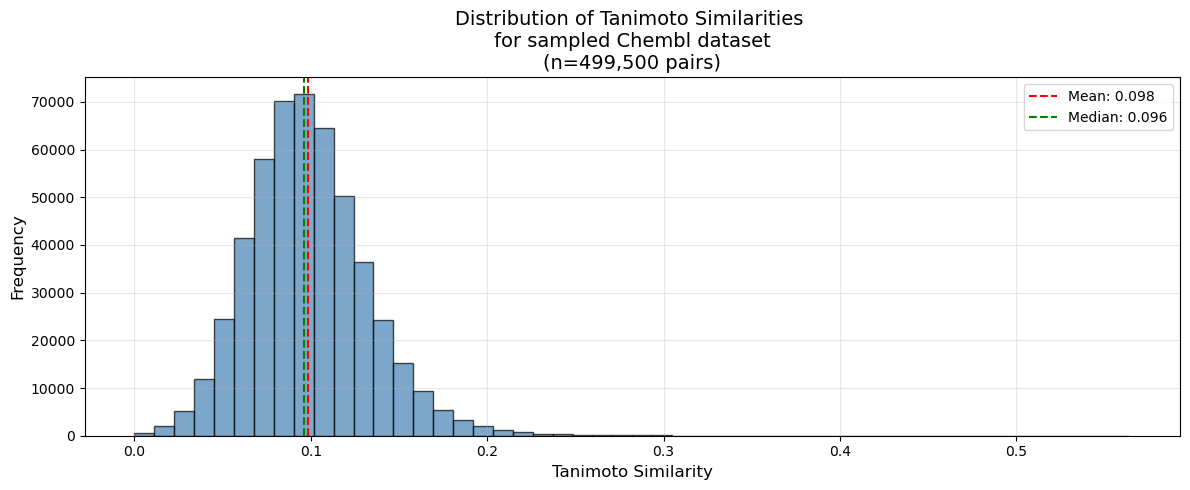


📊 Similarity Statistics:
Number of pairs: 499,500
Mean: 0.0984
Median: 0.0959
Std: 0.0339
Min: 0.0000
Max: 0.5645

📈 Percentiles:
1th: 0.0286
5th: 0.0483
10th: 0.0583
25th: 0.0757
50th: 0.0959
75th: 0.1181
90th: 0.1410
95th: 0.1567
99th: 0.1931


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get all unique pairwise similarities (excluding diagonal and duplicates)
# Upper triangle indices (k=1 excludes diagonal)
upper_tri_indices = np.triu_indices_from(similarity_matrix_chembl, k=1)
similarities = similarity_matrix_chembl[upper_tri_indices]

print(f"Total pairwise comparisons: {len(similarities):,}")

# ============================================
# 1. BASIC HISTOGRAM
# ============================================
plt.figure(figsize=(12, 5))

plt.hist(similarities, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Tanimoto Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Tanimoto Similarities \n for sampled Chembl dataset \n(n={len(similarities):,} pairs)', fontsize=14)
plt.grid(True, alpha=0.3)

# Add statistics
plt.axvline(np.mean(similarities), color='red', linestyle='--', 
            label=f'Mean: {np.mean(similarities):.3f}')
plt.axvline(np.median(similarities), color='green', linestyle='--', 
            label=f'Median: {np.median(similarities):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 3. PRINT STATISTICS
# ============================================
print("\nSimilarity Statistics:")
print(f"Number of pairs: {len(similarities):,}")
print(f"Mean: {np.mean(similarities):.4f}")
print(f"Median: {np.median(similarities):.4f}")
print(f"Std: {np.std(similarities):.4f}")
print(f"Min: {np.min(similarities):.4f}")
print(f"Max: {np.max(similarities):.4f}")

print("\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}th: {np.percentile(similarities, p):.4f}")
